<a href="https://colab.research.google.com/github/fathinahnj/unet-plankton-segmentation/blob/main/kfold_as_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Vjof9rBzJ2QeB82ApBRi")
project = rf.workspace("planktonclassification").project("instance-t20")
version = project.version(4)
dataset = version.download("coco-segmentation")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 47.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to instance-t20-4 in coco-segmentation:: 100%|██████████| 171/171 [00:00<00:00, 8972.95it/s]


In [3]:
%%capture
import os
import gc
import json
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd

from pycocotools.coco import COCO
from sklearn.model_selection import KFold

from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications import (
    ResNet50,
    EfficientNetB4,
    MobileNetV2
)

from sklearn.model_selection import KFold

In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Path & Config

In [5]:
BASE_PATH = "/content/drive/MyDrive/PLANKTON/data/instance/test"
DATA_PATH = "/content/instance-t20-4/valid"

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 20
KFOLD = 5
LR = 1e-5

MODEL_SAVE_DIR = os.path.join(BASE_PATH, "kfold_models")

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

In [7]:
ENCODERS = {
    "resnet50": ResNet50,
    "efficientnetb4": EfficientNetB4,
    "mobilenetv2": MobileNetV2
}

# Memory Management

In [8]:
def clear_memory(model=None):
    """
    Delete model + clear Keras session + force GC.
    Call at the end of every fold to prevent GPU/RAM accumulation.
    """
    if model is not None:
        del model
    K.clear_session()
    gc.collect()

In [9]:
# ── Per-fold result persistence — resume safely after a crash ─────────────
RESULTS_FILE = os.path.join(MODEL_SAVE_DIR, "kfold_results.json")

In [10]:
def load_results():
    """Load previously saved fold results to resume after a crash."""
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            print(f"[resume] Found existing results at {RESULTS_FILE}")
            return json.load(f)
    return {}

In [11]:
def save_results(results):
    """Persist results to disk after every fold — crash-safe."""
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"[checkpoint] Saved to {RESULTS_FILE}")

# Load COCO Dataset

In [12]:
coco_json_path = os.path.join(DATA_PATH, "_annotations.coco.json")

coco = COCO(coco_json_path)

all_images = coco.dataset["images"]
all_annotations = coco.dataset["annotations"]
categories = coco.dataset["categories"]

image_ids = np.array([img["id"] for img in all_images])

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [13]:
# shared coco object

coco_kfold_obj = COCO()
coco_kfold_obj.dataset = {
    "images":      all_images,
    "annotations": all_annotations,
    "categories":  categories
}
coco_kfold_obj.createIndex()

creating index...
index created!


# Image Path

In [14]:
def get_image_path(file_name):
    return os.path.join(DATA_PATH, file_name)

# Mask Creation

In [15]:
def create_mask(image_info, coco_instance):

    height = image_info["height"]
    width = image_info["width"]

    mask = np.zeros((height, width), dtype=np.uint8)

    ann_ids = coco_instance.getAnnIds(imgIds=image_info["id"])
    anns = coco_instance.loadAnns(ann_ids)

    for ann in anns:
        m = coco_instance.annToMask(ann)
        mask[m == 1] = 1

    return mask

In [16]:
def load_image_and_mask(img_info, augment=False):
    """Load a single image + binary mask, optionally apply color augmentation."""
    img_path = os.path.join(DATA_PATH, img_info["file_name"])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) / 255.0

    mask = create_mask(img_info, coco_kfold_obj)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask = np.expand_dims(mask, axis=-1)

    if augment:
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
        image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
        image = tf.clip_by_value(image, 0.0, 1.0).numpy()

    return image, mask

In [17]:
def load_image_and_mask_augmented(img_info, apply_augmentation=True):

    img_path = os.path.join(data_path, img_info["file_name"])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) / 255.0

    mask = create_mask(img_info, coco_kfold_obj)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST)

    mask = np.expand_dims(mask, axis=-1)

    if apply_augmentation:
        image = augment_color(image)

    return image, mask

# tf.data Pipeline

In [18]:
def build_dataset(img_subset, augment=False, batch_size=BATCH_SIZE):
    """
    Build a tf.data.Dataset from a list of COCO image dicts.
    Loads lazily — no full numpy array materialised in memory.
    """
    def generator():
        for img_info in img_subset:
            image, mask = load_image_and_mask(img_info, augment=augment)
            yield image.astype(np.float32), mask.astype(np.float32)

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32)
        )
    )

    dataset = (
        dataset
        .shuffle(buffer_size=len(img_subset), reshuffle_each_iteration=True)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return dataset

# Dice Score

In [19]:
def dice_score(y_true, y_pred):

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred)

    return (2. * intersection + 1e-7) / (union + 1e-7)

# Loss Function

In [20]:
def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + 1e-7) / (union + 1e-7)

    return bce + (1 - dice)

# UNet Builder + Encoders

In [21]:
# Per-encoder: skip layer names + bridge layer name
ENCODER_CONFIG = {
    "resnet50": {
        "skips":  [
            "conv1_relu",
            "conv2_block3_out",
            "conv3_block4_out",
            "conv4_block6_out"
        ],
        "bridge": "conv5_block3_out",
        "num_extra_upsamples": 1 # Decoder ends at 112x112, need 1 more to reach 224x224
    },
    "efficientnetb4": {
        "skips":  [
            "block2a_activation",
            "block3a_activation",
            "block4a_activation"
            # block6a_activation intentionally excluded — spatial mismatch at 224x224
        ],
        "bridge": "top_activation",
        "num_extra_upsamples": 2 # Decoder ends at 56x56, need 2 more to reach 224x224
    },
    "mobilenetv2": {
        "skips":  [
            "block_1_expand_relu",
            "block_3_expand_relu",
            "block_6_expand_relu",
            "block_13_expand_relu"
        ],
        "bridge": "block_16_project",
        "num_extra_upsamples": 1 # Decoder ends at 112x112, need 1 more to reach 224x224
    }
}

# Filter sequences for the extra upsampling blocks
EXTRA_UPSAMPLE_FILTER_SEQUENCES = [
    [128, 64],  # Filters for the first extra upsample block
    [32, 16]    # Filters for the second extra upsample block
]

In [22]:
def build_unet_with_encoder(encoder_name):
    """
    Build a U-Net with the specified pretrained encoder.
    Supported: 'resnet50', 'efficientnetb4', 'mobilenetv2'.

    Fix: the old extra-upsample loop used fixed UpSampling2D(2,2) blocks
    which overshot the target resolution (ResNet → 448px, EfficientNet → 896px).
    Replaced with layers.Resizing(IMG_SIZE, IMG_SIZE) as the final step so
    output is always exactly 224×224 regardless of how many skips each encoder has.
    num_extra_upsamples is kept in ENCODER_CONFIG for documentation purposes.
    """
    config       = ENCODER_CONFIG[encoder_name]
    EncoderClass = ENCODERS[encoder_name]

    encoder = EncoderClass(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    skips  = [encoder.get_layer(name).output for name in config["skips"]]
    x      = encoder.get_layer(config["bridge"]).output

    # Decoder: upsample + skip connections
    for skip in reversed(skips):
        x = layers.UpSampling2D(size=(2, 2))(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)

    # Resize to IMG_SIZE — guarantees 224×224 output for all encoders.
    # Replaces the old fixed UpSampling2D loop that overshot target resolution.
    x = layers.Resizing(IMG_SIZE, IMG_SIZE, interpolation="bilinear")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return Model(encoder.input, outputs)

# K-Fold Setup

In [23]:
kf = KFold(n_splits=KFOLD, shuffle=True, random_state=42)
encoder_results = load_results()

def run_kfold_for_encoder(encoder_name):
    if encoder_name in encoder_results and \
       len(encoder_results[encoder_name]) == KFOLD:
        print(f"[skip] {encoder_name} already complete — loaded from checkpoint")
        return

    print(f"\n{'='*40}\n  ENCODER: {encoder_name.upper()}\n{'='*40}")

    fold_scores = encoder_results.get(encoder_name, [])
    start_fold  = len(fold_scores)

    if start_fold > 0:
        print(f"[resume] Resuming from fold {start_fold + 1}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(image_ids)):
        if fold < start_fold:
            continue

        print(f"\n----- Fold {fold + 1} / {KFOLD} -----")

        train_id_set = set(image_ids[train_idx])
        val_id_set   = set(image_ids[val_idx])

        train_imgs = [img for img in all_images if img["id"] in train_id_set]
        val_imgs   = [img for img in all_images if img["id"] in val_id_set]

        train_ds = build_dataset(train_imgs, augment=False, batch_size=BATCH_SIZE)
        val_ds   = build_dataset(val_imgs,   augment=False, batch_size=BATCH_SIZE)

        model = build_unet_with_encoder(encoder_name)
        model.compile(optimizer=Adam(LR), loss=bce_dice_loss)

        best_model_path = os.path.join(
            MODEL_SAVE_DIR,
            f"{encoder_name}_fold_{fold + 1}_best.h5"
        )

        callbacks = [
            EarlyStopping(monitor="val_loss", patience=5,
                          restore_best_weights=True, verbose=1),
            ModelCheckpoint(filepath=best_model_path, monitor="val_loss",
                            save_best_only=True, verbose=1)
        ]

        model.fit(train_ds, validation_data=val_ds,
                  epochs=EPOCHS, callbacks=callbacks, verbose=1)

        fold_dice = []
        for batch_imgs_np, batch_masks_np in val_ds:
            preds     = model.predict(batch_imgs_np, verbose=0)
            preds_bin = (preds > 0.3).astype(np.uint8)
            for i in range(len(batch_masks_np)):
                d = dice_score(batch_masks_np[i, :, :, 0].numpy(),
                               preds_bin[i, :, :, 0])
                fold_dice.append(d)

        mean_dice = np.mean(fold_dice)
        fold_scores.append(mean_dice)
        print(f"Fold {fold + 1} Dice: {mean_dice:.4f}")

        encoder_results[encoder_name] = fold_scores
        save_results(encoder_results)

        del train_ds, val_ds
        clear_memory(model)
        model = None

    scores = encoder_results[encoder_name]
    print(f"\n{encoder_name} — Avg Dice: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

[resume] Found existing results at /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/kfold_results.json


In [ ]:
run_kfold_for_encoder("resnet50")


  ENCODER: RESNET50

----- Fold 1 / 5 -----
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
     17/Unknown 154s 4s/step - loss: 1.4380   

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



Epoch 1: val_loss improved from None to 1.25239, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_1_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - loss: 1.2965 - val_loss: 1.2524
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - loss: 1.0565
Epoch 2: val_loss did not improve from 1.25239
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 492ms/step - loss: 0.9682 - val_loss: 1.3775
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - loss: 0.6171
Epoch 3: val_loss did not improve from 1.25239
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 511ms/step - loss: 0.5383 - val_loss: 1.7543
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.4200
Epoch 4: val_loss did not improve from 1.25239
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 504ms/step - loss: 0.3788 - val_loss: 1.8650
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.3256
Epoch 5: val_loss did not improve from 1.25239
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 503ms/step - loss: 0.3319 - val_loss: 1.9330
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/


Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_2_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - loss: 1.3019 - val_loss: 1.2097
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - loss: 1.0067
Epoch 2: val_loss did not improve from 1.20972
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 496ms/step - loss: 0.9326 - val_loss: 1.3543
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.6037
Epoch 3: val_loss did not improve from 1.20972
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 730ms/step - loss: 0.5632 - val_loss: 1.5442
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 0.3852
Epoch 4: val_loss did not improve from 1.20972
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 510ms/step - loss: 0.3910 - val_loss: 1.6262
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - loss: 0.3417
Epoch 5: val_loss did not improve from 1.20972
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 506ms/step - loss: 0.3113 - val_loss: 1.6825
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms


Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_3_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - loss: 1.3075 - val_loss: 1.2682
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - loss: 1.0932
Epoch 2: val_loss did not improve from 1.26816
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 493ms/step - loss: 1.0088 - val_loss: 1.4298
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - loss: 0.6287
Epoch 3: val_loss did not improve from 1.26816
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 512ms/step - loss: 0.5562 - val_loss: 1.8621
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - loss: 0.4093
Epoch 4: val_loss did not improve from 1.26816
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 517ms/step - loss: 0.4186 - val_loss: 1.9391
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 0.3436
Epoch 5: val_loss did not improve from 1.26816
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 507ms/step - loss: 0.3316 - val_loss: 1.9837
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/

Fold 3 Dice: 0.0002
[checkpoint] Saved to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/kfold_results.json

----- Fold 4 / 5 -----
Epoch 1/20
     17/Unknown 127s 4s/step - loss: 1.2248  
Epoch 1: val_loss improved from None to 1.22420, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_4_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - loss: 1.1351 - val_loss: 1.2242
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 0.8738
Epoch 2: val_loss did not improve from 1.22420
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 504ms/step - loss: 0.7418 - val_loss: 1.4786
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - loss: 0.4536
Epoch 3: val_loss did not improve from 1.22420
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 527ms/step - loss: 0.4296 - val_loss: 1.6562
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - loss: 0.3431
Epoch 4: val_loss did not improve from 1.22420
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 519ms/step - loss: 0.3426 - val_loss: 1.6723
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - loss: 0.3561
Epoch 5: val_loss did not improve from 1.22420
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 517ms/step - loss: 0.3447 - val_loss: 1.7470
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/


Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/resnet50_fold_5_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - loss: 1.1102 - val_loss: 1.2519
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - loss: 0.7464
Epoch 2: val_loss did not improve from 1.25187
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 495ms/step - loss: 0.6376 - val_loss: 1.5568
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - loss: 0.3983
Epoch 3: val_loss did not improve from 1.25187
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 497ms/step - loss: 0.4124 - val_loss: 1.7212
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.3229
Epoch 4: val_loss did not improve from 1.25187
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 500ms/step - loss: 0.3159 - val_loss: 1.7115
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - loss: 0.2781
Epoch 5: val_loss did not improve from 1.25187
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 510ms/step - loss: 0.3179 - val_loss: 1.7427
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms

In [ ]:
run_kfold_for_encoder("efficientnetb4")


  ENCODER: EFFICIENTNETB4
[resume] Resuming from fold 4

----- Fold 4 / 5 -----
Epoch 1/20
     17/Unknown 319s 7s/step - loss: 1.4476   

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



Epoch 1: val_loss improved from None to 1.22936, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/efficientnetb4_fold_4_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/efficientnetb4_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 379s 11s/step - loss: 1.2683 - val_loss: 1.2294
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 0.8277
Epoch 2: val_loss did not improve from 1.22936
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 391ms/step - loss: 0.7720 - val_loss: 1.4271
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.6135
Epoch 3: val_loss did not improve from 1.22936
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - loss: 0.5857 - val_loss: 1.5471
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.5022
Epoch 4: val_loss did not improve from 1.22936
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 399ms/step - loss: 0.4873 - val_loss: 1.6118
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - loss: 0.4427
Epoch 5: val_loss did not improve from 1.22936
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step - loss: 0.4590 - val_loss: 1.6960
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/efficientnetb4_fold_5_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 297s 8s/step - loss: 1.1169 - val_loss: 1.3024
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 0.7772
Epoch 2: val_loss did not improve from 1.30235
17/17 ━━━━━━━━━━━━━━━━━━━━ 53s 390ms/step - loss: 0.7245 - val_loss: 1.5612
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 0.5380
Epoch 3: val_loss did not improve from 1.30235
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 395ms/step - loss: 0.5695 - val_loss: 1.8178
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 0.4908
Epoch 4: val_loss did not improve from 1.30235
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 400ms/step - loss: 0.4859 - val_loss: 1.9360
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 0.4696
Epoch 5: val_loss did not improve from 1.30235
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 388ms/step - loss: 0.4442 - val_loss: 1.9242
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
run_kfold_for_encoder("mobilenetv2")


  ENCODER: MOBILENETV2
[resume] Resuming from fold 4

----- Fold 4 / 5 -----
Epoch 1/20
     17/Unknown 160s 4s/step - loss: 1.7962  

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.



Epoch 1: val_loss improved from None to 1.19527, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 194s 6s/step - loss: 1.5153 - val_loss: 1.1953
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - loss: 1.1512
Epoch 2: val_loss improved from 1.19527 to 1.07169, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 508ms/step - loss: 1.1022 - val_loss: 1.0717
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - loss: 0.9303
Epoch 3: val_loss improved from 1.07169 to 0.97214, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 635ms/step - loss: 0.8646 - val_loss: 0.9721
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - loss: 0.7392
Epoch 4: val_loss did not improve from 0.97214
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 440ms/step - loss: 0.6734 - val_loss: 1.1061
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - loss: 0.5820
Epoch 5: val_loss improved from 0.97214 to 0.91427, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 626ms/step - loss: 0.5234 - val_loss: 0.9143
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - loss: 0.4753
Epoch 6: val_loss did not improve from 0.91427
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 450ms/step - loss: 0.4370 - val_loss: 1.2711
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 0.3956
Epoch 7: val_loss did not improve from 0.91427
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 457ms/step - loss: 0.3571 - val_loss: 1.0794
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - loss: 0.3149
Epoch 8: val_loss improved from 0.91427 to 0.58713, saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5



Epoch 8: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_4_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 645ms/step - loss: 0.3608 - val_loss: 0.5871
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - loss: 0.3297
Epoch 9: val_loss did not improve from 0.58713
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - loss: 0.3718 - val_loss: 0.8220
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - loss: 0.3272
Epoch 10: val_loss did not improve from 0.58713
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 454ms/step - loss: 0.2986 - val_loss: 0.9020
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - loss: 0.2895
Epoch 11: val_loss did not improve from 0.58713
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 453ms/step - loss: 0.2957 - val_loss: 0.8876
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - loss: 0.2401
Epoch 12: val_loss did not improve from 0.58713
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 445ms/step - loss: 0.2624 - val_loss: 0.7295
Epoch 13/20
17/17 ━━━━━━━━━━━━━━━━━━


Epoch 1: finished saving model to /content/drive/MyDrive/PLANKTON/data/instance/test/kfold_models/mobilenetv2_fold_5_best.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - loss: 1.0435 - val_loss: 1.0358
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - loss: 0.8101
Epoch 2: val_loss did not improve from 1.03578
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 446ms/step - loss: 0.7375 - val_loss: 1.2123
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - loss: 0.6019
Epoch 3: val_loss did not improve from 1.03578
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 458ms/step - loss: 0.5646 - val_loss: 1.4158
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - loss: 0.5183
Epoch 4: val_loss did not improve from 1.03578
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - loss: 0.4995 - val_loss: 1.4400
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - loss: 0.4106
Epoch 5: val_loss did not improve from 1.03578
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 456ms/step - loss: 0.4316 - val_loss: 1.3962
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 413

# Result Comparison

In [24]:
comparison = []

for encoder, scores in encoder_results.items():

    comparison.append({
        "Encoder": encoder,
        "Fold1": scores[0],
        "Fold2": scores[1],
        "Fold3": scores[2],
        "Fold4": scores[3],
        "Fold5": scores[4],
        "Average Dice": np.mean(scores),
        "Std Dice": np.std(scores)
    })

df = pd.DataFrame(comparison)
df = df.sort_values("Average Dice", ascending=False)

df

,Encoder,Fold1,Fold2,Fold3,Fold4,Fold5,Average Dice,Std Dice
1,mobilenetv2,0.001260,0.122608,0.483897,0.567267,1.282996e-01,0.260666,0.222580
2,efficientnetb4,0.000425,0.000263,0.000554,0.000207,3.581134e-11,0.000290,0.000189
0,resnet50,0.000394,0.000191,0.000172,0.000149,4.381590e-11,0.000181,0.000126


In [25]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1_RQGw1EQnQjHUjt2eTlTRLduU2Vu1pGlyx-jO1YsDPc/edit#gid=0


# Debugging

In [26]:
def debug_encoder_shapes(encoder_name):
    config = ENCODER_CONFIG[encoder_name]
    EncoderClass = ENCODERS[encoder_name]

    encoder = EncoderClass(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=None  # faster, no download
    )

    print(f"\n=== {encoder_name} ===")
    for name in config["skips"]:
        layer = encoder.get_layer(name)
        print(f"  skip '{name}': {layer.output.shape}") # Fixed here

    bridge = encoder.get_layer(config["bridge"])
    print(f"  bridge '{config['bridge']}': {bridge.output.shape}") # Fixed here
    print(f"  num_extra_upsamples: {config['num_extra_upsamples']}") # Fixed typo here

for enc in ENCODERS.keys():
    debug_encoder_shapes(enc)


=== resnet50 ===
  skip 'conv1_relu': (None, 112, 112, 64)
  skip 'conv2_block3_out': (None, 56, 56, 256)
  skip 'conv3_block4_out': (None, 28, 28, 512)
  skip 'conv4_block6_out': (None, 14, 14, 1024)
  bridge 'conv5_block3_out': (None, 7, 7, 2048)
  num_extra_upsamples: 1

=== efficientnetb4 ===
  skip 'block2a_activation': (None, 56, 56, 144)
  skip 'block3a_activation': (None, 28, 28, 192)
  skip 'block4a_activation': (None, 14, 14, 336)
  bridge 'top_activation': (None, 7, 7, 1792)
  num_extra_upsamples: 2

=== mobilenetv2 ===
  skip 'block_1_expand_relu': (None, 112, 112, 96)
  skip 'block_3_expand_relu': (None, 56, 56, 144)
  skip 'block_6_expand_relu': (None, 28, 28, 192)
  skip 'block_13_expand_relu': (None, 14, 14, 576)
  bridge 'block_16_project': (None, 7, 7, 320)
  num_extra_upsamples: 1


In [27]:
# Cek ukuran dataset dan distribusi mask
print(f"Total images: {len(all_images)}")
print(f"Total annotations: {len(all_annotations)}")

# Cek berapa banyak gambar yang punya mask vs kosong
has_mask = 0
empty_mask = 0
for img in all_images:
    ann_ids = coco_kfold_obj.getAnnIds(imgIds=img["id"])
    if len(ann_ids) > 0:
        has_mask += 1
    else:
        empty_mask += 1

print(f"Images with mask: {has_mask}")
print(f"Images without mask (background only): {empty_mask}")
print(f"Class imbalance ratio: {empty_mask}/{has_mask} = {empty_mask/max(has_mask,1):.1f}x")

Total images: 168
Total annotations: 321
Images with mask: 168
Images without mask (background only): 0
Class imbalance ratio: 0/168 = 0.0x


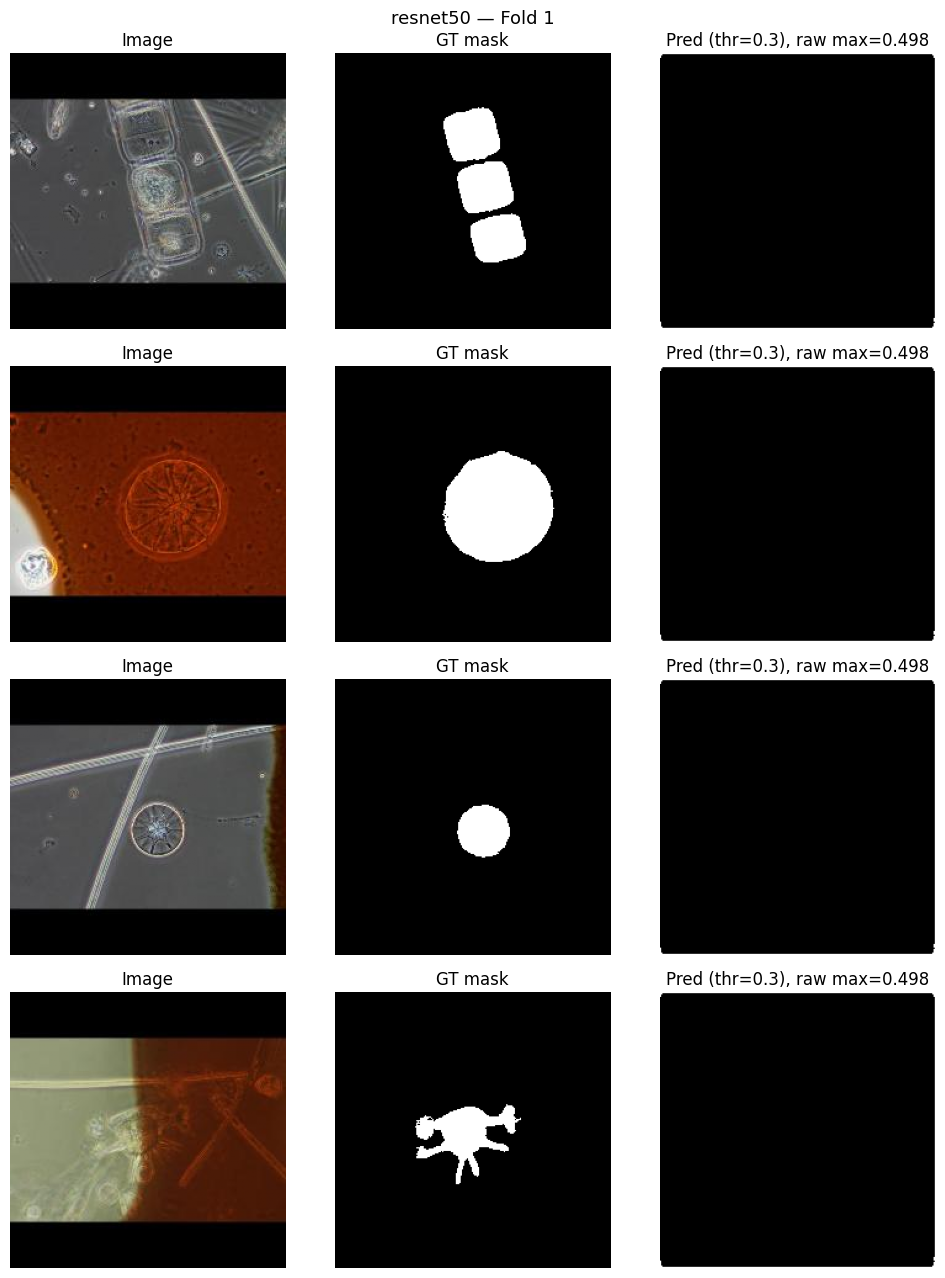

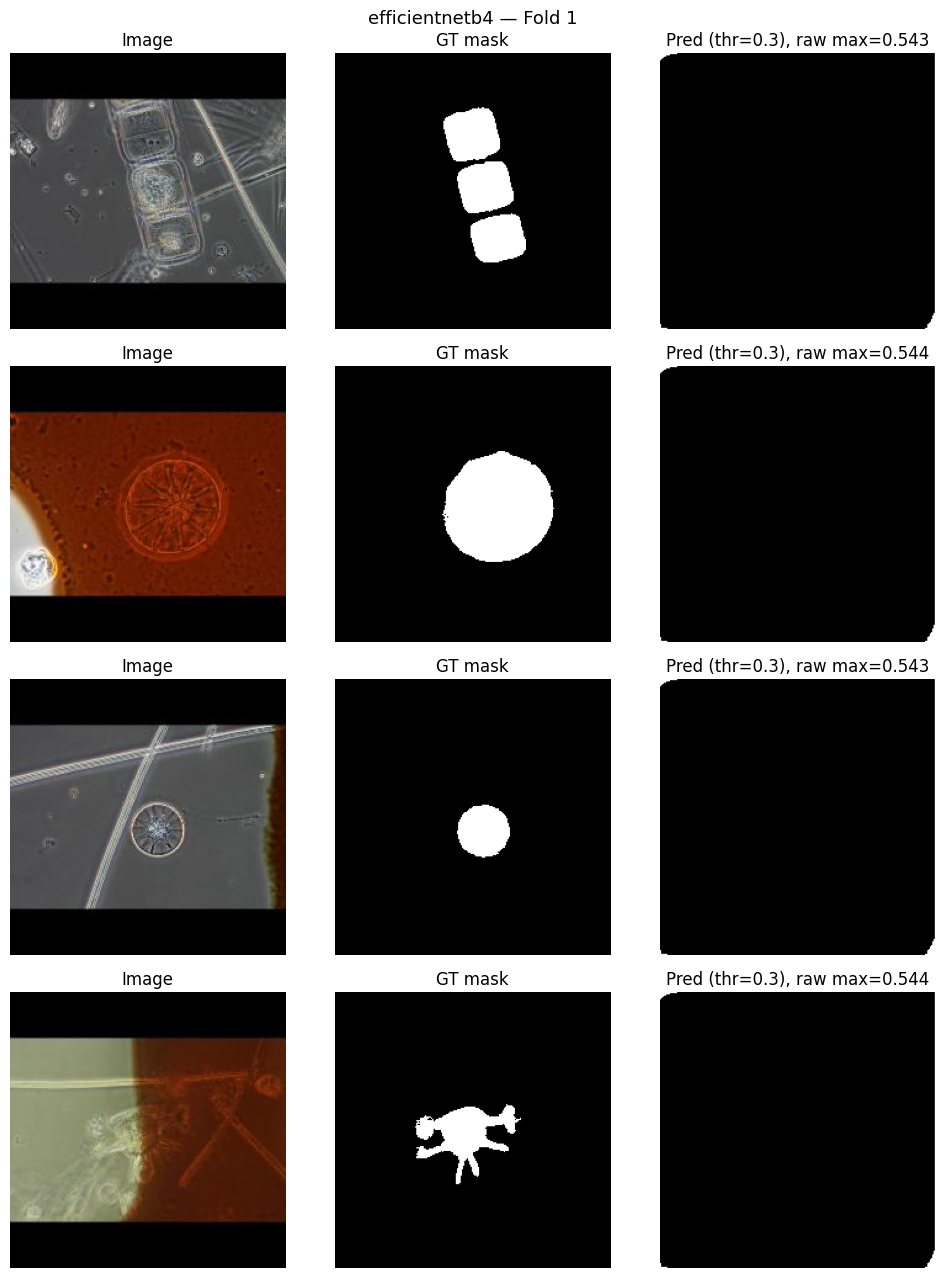

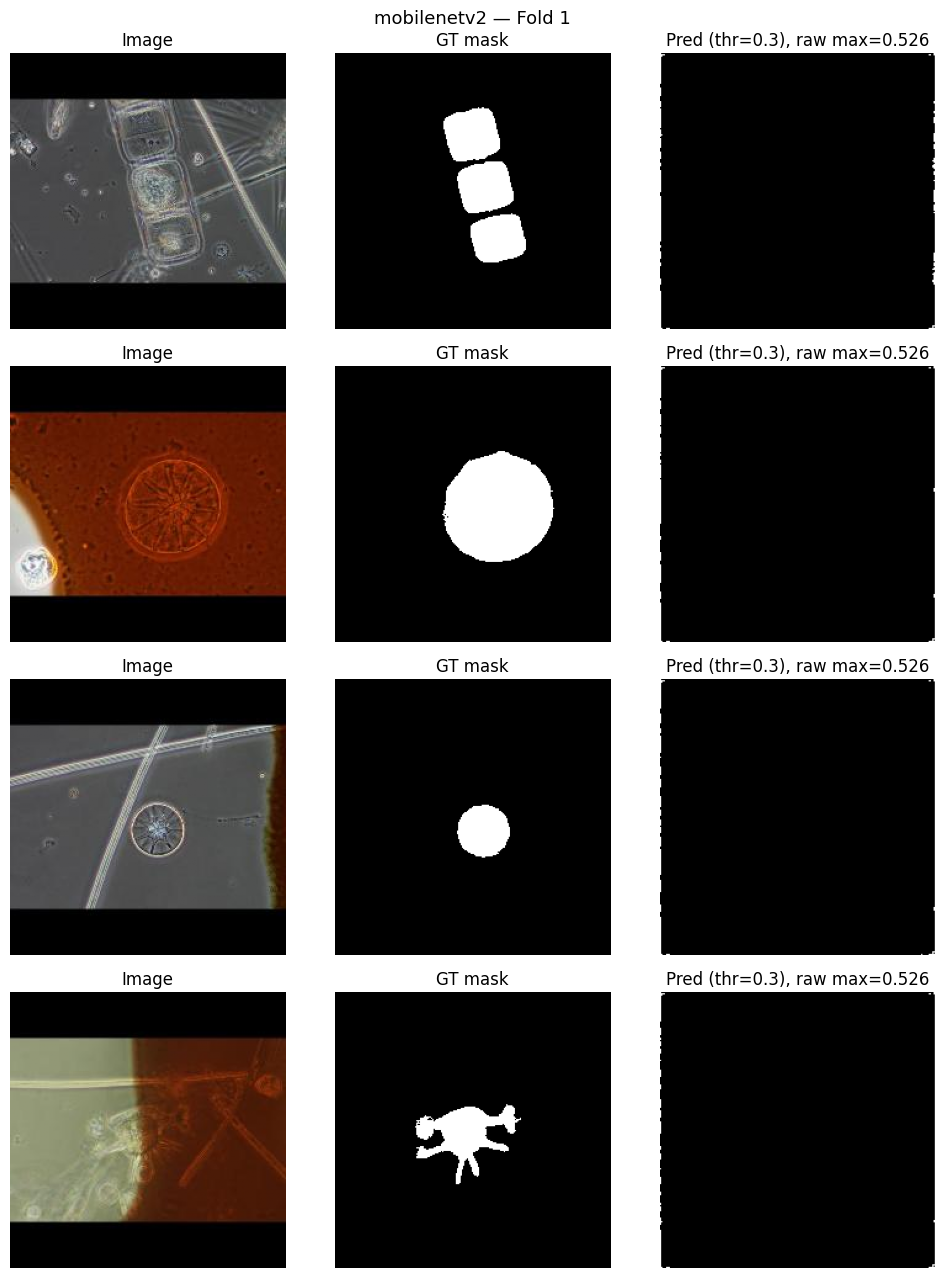

In [28]:
# Visualisasi sample: image, ground truth mask, predicted mask
import matplotlib.pyplot as plt

def visualize_sample_prediction(encoder_name, fold=1):
    model_path = os.path.join(MODEL_SAVE_DIR, f"{encoder_name}_fold_{fold}_best.h5")
    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        return

    model = tf.keras.models.load_model(model_path, compile=False)

    # Ambil 4 sample dari val set fold 1
    kf = KFold(n_splits=KFOLD, shuffle=True, random_state=42)
    for f, (train_idx, val_idx) in enumerate(kf.split(image_ids)):
        if f == fold - 1:
            break

    val_imgs = [img for img in all_images if img["id"] in set(image_ids[val_idx])][:4]

    fig, axes = plt.subplots(4, 3, figsize=(10, 13))
    fig.suptitle(f"{encoder_name} — Fold {fold}", fontsize=13)

    for i, img_info in enumerate(val_imgs):
        image, mask = load_image_and_mask(img_info)
        pred = model.predict(np.expand_dims(image, 0), verbose=0)[0]
        pred_bin = (pred > 0.3).astype(np.uint8)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask[:, :, 0], cmap="gray")
        axes[i, 1].set_title(f"GT mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin[:, :, 0], cmap="gray")
        axes[i, 2].set_title(f"Pred (thr=0.3), raw max={pred.max():.3f}")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, f"viz_{encoder_name}_fold{fold}.png"), dpi=100)
    plt.show()
    clear_memory(model)

# Cek semua encoder, fold 1
for enc in ["resnet50", "efficientnetb4", "mobilenetv2"]:
    visualize_sample_prediction(enc, fold=1)